In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, precision_recall_curve, auc

train = pd.read_csv("./train_c.csv")
test = pd.read_csv("./test_c.csv")

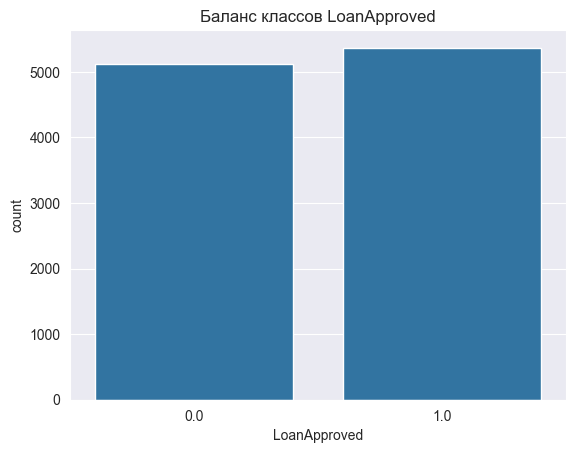

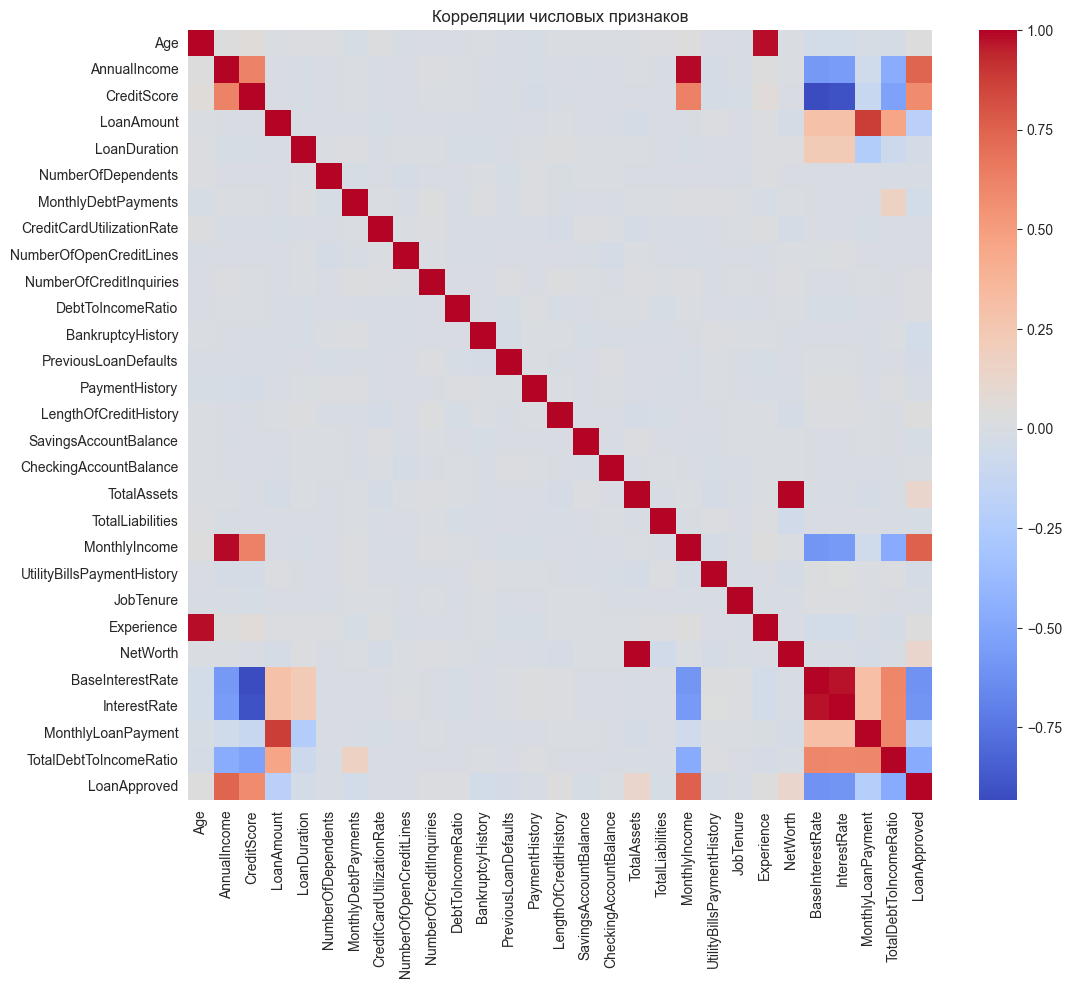

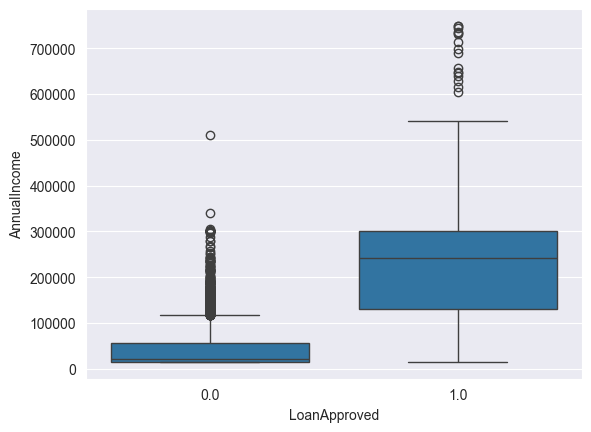

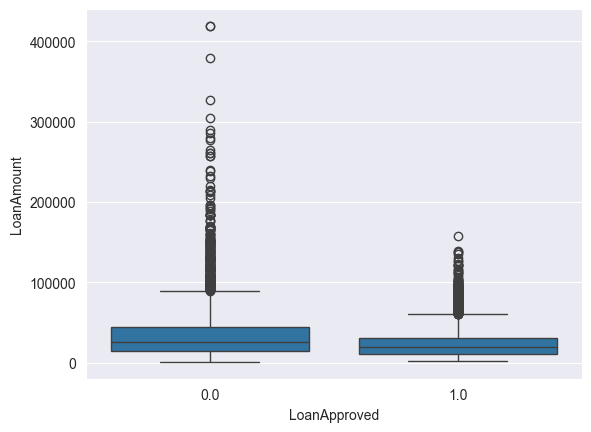

In [2]:
sns.countplot(x=train["LoanApproved"])
plt.title("Баланс классов LoanApproved")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(train.select_dtypes(include=[np.number]).corr(), cmap="coolwarm")
plt.title("Корреляции числовых признаков")
plt.show()

sns.boxplot(x="LoanApproved", y="AnnualIncome", data=train)
plt.show()
sns.boxplot(x="LoanApproved", y="LoanAmount", data=train)
plt.show()


In [3]:
for df in [train, test]:
    if "ApplicationDate" in df.columns:
        df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
        df["AppYear"] = df["ApplicationDate"].dt.year
        df["AppMonth"] = df["ApplicationDate"].dt.month
        df["AppDay"] = df["ApplicationDate"].dt.day
        df.drop(columns=["ApplicationDate"], inplace=True)


num_cols = train.select_dtypes(include=[np.number]).columns.drop("LoanApproved")
imputer_num = SimpleImputer(strategy="mean")
train[num_cols] = imputer_num.fit_transform(train[num_cols])
test[num_cols] = imputer_num.transform(test[num_cols])

cat_cols = train.select_dtypes(exclude=[np.number]).columns
if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy="most_frequent")
    train[cat_cols] = imputer_cat.fit_transform(train[cat_cols])
    test[cat_cols] = imputer_cat.transform(test[cat_cols])

for col in train.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

y = train["LoanApproved"]
X = train.drop("LoanApproved", axis=1)

# Согласование признаков
ids = test["ID"]
X_test = test.drop(columns=["ID"])
X_test = X_test[X.columns]


In [4]:
print("NaN в LoanApproved:", train["LoanApproved"].isna().sum())

train["LoanApproved"] = train["LoanApproved"].fillna(train["LoanApproved"].median())

y = train["LoanApproved"]
X = train.drop("LoanApproved", axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


NaN в LoanApproved: 530


In [5]:
from sklearn.tree import DecisionTreeClassifier

class MyBagging:
    def __init__(self, base_model_cls=DecisionTreeClassifier, n_estimators=20, base_params=None, random_state=42):
        self.base_model_cls = base_model_cls
        self.n_estimators = n_estimators
        self.base_params = base_params or {}
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n = X.shape[0]
        self.models = []
        for i in range(self.n_estimators):
            idx = rng.choice(n, n, replace=True)
            m = self.base_model_cls(**self.base_params)
            m.fit(X.iloc[idx], y.iloc[idx])
            self.models.append(m)
        return self

    def predict_proba(self, X):
        probs = np.column_stack([m.predict_proba(X)[:,1] for m in self.models])
        return probs.mean(axis=1)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

my_bag = MyBagging(DecisionTreeClassifier, n_estimators=25, base_params={"max_depth":5}, random_state=42)
my_bag.fit(X_train, y_train)
print("MyBagging ROC-AUC:", roc_auc_score(y_val, my_bag.predict_proba(X_val)))


MyBagging ROC-AUC: 0.9752143471927966


In [6]:
from sklearn.tree import DecisionTreeRegressor

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -20, 20)))

class MyLogitGB:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.models = []
        self.F0 = 0.0

    def fit(self, X, y):
        p0 = np.clip(y.mean(), 1e-6, 1-1e-6)
        self.F0 = np.log(p0 / (1 - p0))
        F = np.full(X.shape[0], self.F0, dtype=float)
        self.models = []
        rng = np.random.RandomState(self.random_state)
        for t in range(self.n_estimators):
            p = sigmoid(F)
            r = y.values - p
            m = DecisionTreeRegressor(max_depth=self.max_depth, random_state=rng.randint(0, 10**6))
            m.fit(X, r)
            F += self.learning_rate * m.predict(X)
            self.models.append(m)
        return self

    def predict_proba(self, X):
        F = np.full(X.shape[0], self.F0, dtype=float)
        for m in self.models:
            F += self.learning_rate * m.predict(X)
        return sigmoid(F)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

my_gb = MyLogitGB(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)
my_gb.fit(X_train, y_train)
print("MyLogitGB ROC-AUC:", roc_auc_score(y_val, my_gb.predict_proba(X_val)))


MyLogitGB ROC-AUC: 0.976660983845339


In [7]:
def my_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def my_precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def my_recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def my_f1(y_true, y_pred):
    p = my_precision(y_true, y_pred)
    r = my_recall(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

def my_auc_roc(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return auc(fpr, tpr)

def my_auc_pr(y_true, y_score):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    return auc(recall, precision)

y_pred = my_gb.predict(X_val)
y_proba = my_gb.predict_proba(X_val)

print("Accuracy:", my_accuracy(y_val.values, y_pred))
print("Precision:", my_precision(y_val.values, y_pred))
print("Recall:", my_recall(y_val.values, y_pred))
print("F1:", my_f1(y_val.values, y_pred))
print("ROC-AUC:", my_auc_roc(y_val.values, y_proba))
print("PR-AUC:", my_auc_pr(y_val.values, y_proba))


Accuracy: 0.9165154264972777
Precision: 0.9170854271356784
Recall: 0.9279661016949152
F1: 0.9224936815501263
ROC-AUC: 0.976660983845339
PR-AUC: 0.9803284331524157


In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "SklearnGB": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=600,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=3.0,
        random_state=42,
        verbose=0
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    print(f"{name} ROC-AUC:", roc_auc_score(y_val, proba))


SklearnGB ROC-AUC: 0.9821578720868642
XGBoost ROC-AUC: 0.9843576204978812
[LightGBM] [Info] Number of positive: 4717, number of negative: 4096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4686
[LightGBM] [Info] Number of data points in the train set: 8813, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.535232 -> initscore=0.141162
[LightGBM] [Info] Start training from score 0.141162
LightGBM ROC-AUC: 0.983642578125
CatBoost ROC-AUC: 0.9847962460275423


In [9]:
best_cat = CatBoostClassifier(
    iterations=600,
    depth=7,
    learning_rate=0.051472716149401895,
    l2_leaf_reg=9.462120317915966,
    random_state=42,
    verbose=0
)

best_cat.fit(X, y)

preds = best_cat.predict_proba(X_test)[:,1]

submission = pd.DataFrame({"ID": ids, "LoanApproved": preds})
submission.to_csv("./submission.csv", index=False)

print("Файл submission.csv сохранён:", submission.shape)

Файл submission.csv сохранён: (5000, 2)
